# Data Fusion: Creating a Continuous 26-Year SLA Timeline
Description: This notebook merges the Landsat/Sentinel observations with the MODIS data. To have a clean starting and end point, in every year the lowest SLA value is identified and assigned to the 1. May and 31. October. Furthermore only the time after 2017 will merge both datasets, before 2017 only the MODIS data will be considered. The result is a gap-filled 26-year timeline of Snowline Altitude (SLA) for each glacier, with only MODIS data before 2017 and a merged time series after 2017. For analysis purposes the alignment between MODIS and Landsat/Sentinel-2 gets quantified, by calculating mean average difference (MAD) in the Landsat/Sentinel SLA elevation and the MODIS SLA elevation on the same day.

*The Code in this notebook was written with the help of AI (Gemini, Version 3.1 Pro)*

In [2]:
# Setup and imports
import pandas as pd
import numpy as np
import os
import glob
from IPython.display import display
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


# Define directories 
ls_dir = '../data/LS_Data/weighted_smoothed'
modis_dir = '../data/MODIS_data/predicted_sla'

## 1. Merge the Landsat/Sentinel-2 and MODIS data
In this code the Landsat/Sentinel-2 and MODIS files get loaded and merged after the year 2017. Before 2017 the time series will only consist of MODIS data. Whenever there is a Landsat/Sentinel-2 and MODIS data point on the same day, the Landsat/Sentinel-2 data point is preferred, as it is of higher spatial resolution.

In [2]:
# Get the Landsat files
ls_files = glob.glob(f"{ls_dir}/*.csv")
study_glaciers = ['Ulluchiran', 'Lekziri', 'Caneri', 'Bezengi', 'Dyh-Cu', 'Agashtan', 'Karaugom']

# Dictionary to store the processed dataframes 
merged_datasets = {}

for ls_path in ls_files:
    file_name = os.path.basename(ls_path)
    name = file_name.split('_')[1] 

    if name not in study_glaciers:
        continue
    
    modis_path = f"{modis_dir}/predicted_SLA_{name}_WLS.csv"
    
    if not os.path.exists(modis_path):
        continue
        
    ls_df = pd.read_csv(ls_path)
    modis_df = pd.read_csv(modis_path)

    # Extract the GLIMS ID
    if 'glacier_glims_id' in ls_df.columns:
        current_glims_id = ls_df['glacier_glims_id'].dropna().iloc[0] 
    else:
        current_glims_id = "UNKNOWN"

    # Convert to datetime
    ls_df['date'] = pd.to_datetime(ls_df['time_date-string'])
    modis_df['date'] = pd.to_datetime(modis_df['date'])

    ls_indexed = ls_df.set_index('date')
    modis_indexed = modis_df.set_index('date')

    # Slice Landsat/Sentinel data to >= 2017
    ls_indexed_modern = ls_indexed[ls_indexed.index >= '2017-01-01']

    # Create Daily Calendar
    start_date = modis_indexed.index.min()
    end_date = modis_indexed.index.max()
    master_calendar = pd.DataFrame(index=pd.date_range(start=start_date, end=end_date, freq='D'))
    master_calendar.index.name = 'date'

    # Merge Data
    master_calendar = master_calendar.join(ls_indexed_modern[['SLA_weighted_20day']], how='left')
    master_calendar = master_calendar.join(modis_indexed[['predicted_SLA_smoothed_WLS']], how='left')

    # Priority: Landsat/Sentinel > MODIS
    master_calendar['Final_Composite_SLA'] = master_calendar['SLA_weighted_20day'].fillna(master_calendar['predicted_SLA_smoothed_WLS'])

    # Track Data Source
    conditions = [
        master_calendar['SLA_weighted_20day'].notna(),
        master_calendar['predicted_SLA_smoothed_WLS'].notna()
    ]
    choices = ['Landsat/Sentinel (Observation)', 'MODIS WLS (Proxy)']
    master_calendar['Data_Source'] = np.select(conditions, choices, default='No Data')

    # Clean missing data
    final_clean_df = master_calendar[master_calendar['Data_Source'] != 'No Data'].reset_index()
    final_clean_df['Final_Composite_SLA'] = final_clean_df['Final_Composite_SLA'].round(2)
    final_clean_df['glacier_glims_id'] = current_glims_id
    
    # Store data
    merged_datasets[name] = final_clean_df

print(f"Successfully processed and merged data for {len(merged_datasets)} glaciers.")

Cell 1 Complete: Successfully processed and merged data for 7 glaciers.


## 2. Quantification of the MODIS and Landsat/Sentinel-2 alginment
To quantify how well the combination works, the MAD (mean average difference) between MODIS SLA and Landsat/Sentinel-2 SLA gets calculated between overlapping days. The difference of each overlapping day gets identified and then the mean of all differences is calculated. 

In [3]:
#MAD between MODIS and Landsat/Sentinel-2 on overlapping days 
results = []

for name, df in merged_datasets.items():

    # Find days where both sources have a value
    overlap = df[
        df['SLA_weighted_20day'].notna() &
        df['predicted_SLA_smoothed_WLS'].notna()
    ].copy()

    n = len(overlap)

    if n == 0:
        results.append({
            'Glacier': name,
            'N overlapping days': 0,
            'MAD (m)': None,
        })
        continue

    diff = overlap['predicted_SLA_smoothed_WLS'] - overlap['SLA_weighted_20day']

    mad  = diff.abs().mean()

    results.append({
        'Glacier': name,
        'Overlapping days': n,
        'MAD (m)': round(mad,  1),
    })

alignment_df = (
    pd.DataFrame(results)
    .sort_values('MAD (m)')
    .reset_index(drop=True)
)

print("\nMODIS vs. Landsat/Sentinel-2 SLA alignment (post-2017 overlapping days)")
print(alignment_df.to_string(index=False))


MODIS vs. Landsat/Sentinel-2 SLA alignment (post-2017 overlapping days)
   Glacier  Overlapping days  MAD (m)
   Lekziri               362     83.2
  Agashtan               131     88.1
    Dyh-Cu               135    118.3
  Karaugom               220    122.0
   Bezengi               211    130.4
    Caneri               201    151.6
Ulluchiran               163    209.2


## 3. Fix beginning and end SLA values
In this step a clear starting and endpoint in each year of the SLA time series is defined. It is assumed that on the 1. of May and the 31. of October the glaciers are fully covered by snow. Therefore the lowest measured SLA value gets assigend to both of these dates to have a clean starting and end point. 

In [6]:
# Define output directory
output_dir = '../data/LS_MODIS_combined/combination_post2017'
os.makedirs(output_dir, exist_ok=True)

modern_fusion_summary = []

for name, df in merged_datasets.items():
    current_glims_id = df['glacier_glims_id'].iloc[0]
    
    # Extract year to group by
    df['year'] = df['date'].dt.year
    
    # Find the minimum SLA for each year present in the dataset
    yearly_mins = df.groupby('year')['Final_Composite_SLA'].min().to_dict()
    
    boundary_rows = []
    
    # Generate the boundary points for May 1 and Oct 31 using the yearly minimum
    for year, min_sla in yearly_mins.items():
        # May 1st
        boundary_rows.append({
            'date': pd.Timestamp(f"{year}-05-01"),
            'Final_Composite_SLA': min_sla,
            'Data_Source': 'Assumed Full Snow Cover',
            'glacier_glims_id': current_glims_id,
            'year': year
        })
        # October 31st
        boundary_rows.append({
            'date': pd.Timestamp(f"{year}-10-31"),
            'Final_Composite_SLA': min_sla,
            'Data_Source': 'Assumed Full Snow Cover',
            'glacier_glims_id': current_glims_id,
            'year': year
        })
        
    boundaries_df = pd.DataFrame(boundary_rows)
    
    # To prevent duplicates if data already existed exactly on May 1 or Oct 31, 
    # filter those days from the original dataframe before merging
    df_filtered = df[~((df['date'].dt.month == 5) & (df['date'].dt.day == 1))]
    df_filtered = df_filtered[~((df_filtered['date'].dt.month == 10) & (df_filtered['date'].dt.day == 31))]
    
    # Combine original data with new boundary points
    final_boundaries_df = pd.concat([df_filtered, boundaries_df], ignore_index=True)
    
    # Sort chronologically, drop the temporary 'year' column, and round values
    final_boundaries_df = final_boundaries_df.sort_values('date').drop(columns=['year']).reset_index(drop=True)
    final_boundaries_df['Final_Composite_SLA'] = final_boundaries_df['Final_Composite_SLA'].round(2)
    
    # Export the final dataset
    export_path = f"{output_dir}/COMPOSITE_SLA_{name}_POST2017.csv"
    final_boundaries_df.to_csv(export_path, index=False)
    
    # Log Summary Statistics
    source_counts = final_boundaries_df['Data_Source'].value_counts()
    ls_count = source_counts.get('Landsat/Sentinel (Observation)', 0)
    modis_count = source_counts.get('MODIS WLS (Proxy)', 0)
    boundary_count = source_counts.get('Assumed Full Snow Cover', 0)
    total_days = len(final_boundaries_df)
    
    modern_fusion_summary.append({
        'Glacier': name,
        'Landsat/Sentinel-2 Data': ls_count,
        'MODIS Data': modis_count,
        'Boundary Points': boundary_count,
        'Total Usable Days': total_days,
        'MODIS Contribution (%)': round((modis_count / total_days) * 100, 1) if total_days > 0 else 0
    })

# Show summary
df_summary_modern = pd.DataFrame(modern_fusion_summary).sort_values('Total Usable Days', ascending=False).reset_index(drop=True)
display(df_summary_modern)

,Glacier,Landsat/Sentinel-2 Data,MODIS Data,Boundary Points,Total Usable Days,MODIS Contribution (%)
0,Bezengi,391,1430,52,1873,76.3
1,Karaugom,406,1343,52,1801,74.6
2,Lekziri,585,1145,52,1782,64.3
3,Caneri,411,1294,52,1757,73.6
4,Dyh-Cu,300,1071,52,1423,75.3
5,Ulluchiran,710,564,52,1326,42.5
6,Agashtan,293,882,52,1227,71.9


## 4. Visualise the time series
In this step the full time series from 2000 to 2025, with only MODIS data before 2017 and combined Landsat/Sentinel-2 data after 2017 is visualised. 

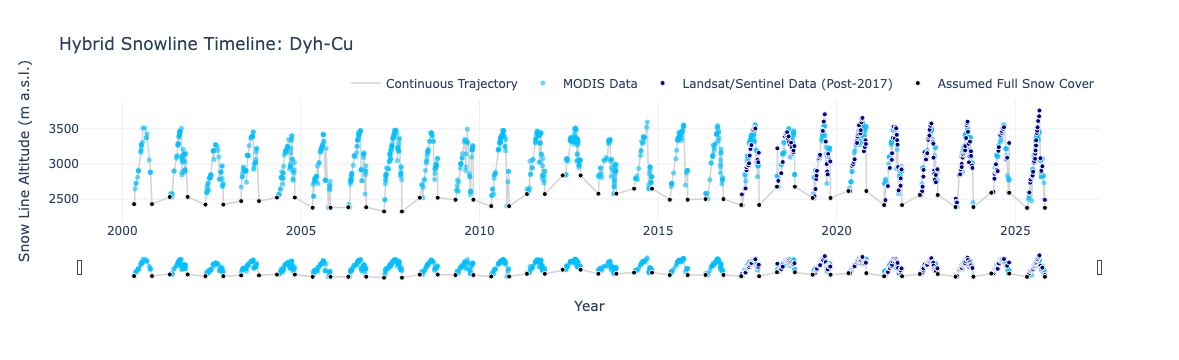

In [4]:
# Set up directory and define glacier
GLACIER_TO_PLOT = 'Dyh-Cu' 
composite_dir = '../data/LS_MODIS_combined/combination_post2017'

composite_path = f"{composite_dir}/COMPOSITE_SLA_{GLACIER_TO_PLOT}_POST2017.csv"

if not os.path.exists(composite_path):
    print(f"Error: Could not find the composite file for {GLACIER_TO_PLOT}. Check path: {composite_path}")
else:
    # Load and prep dates
    df_comp = pd.read_csv(composite_path)
    df_comp['date'] = pd.to_datetime(df_comp['date'])

    # Split the data logically for coloring
    df_ls = df_comp[df_comp['Data_Source'] == 'Landsat/Sentinel (Observation)']
    df_modis = df_comp[df_comp['Data_Source'] == 'MODIS WLS (Proxy)']
    df_boundary = df_comp[df_comp['Data_Source'] == 'Assumed Full Snow Cover']

    # Create figure
    fig_comp = go.Figure()

    # Trace 1: The final Timeline
    fig_comp.add_trace(go.Scatter(
        x=df_comp['date'], 
        y=df_comp['Final_Composite_SLA'],
        mode='lines', 
        name='Continuous Trajectory',
        line=dict(color='lightgrey', width=1.5),
        hoverinfo='skip'
    ))

    # Trace 2: The MODIS Proxy Points 
    fig_comp.add_trace(go.Scatter(
        x=df_modis['date'], 
        y=df_modis['Final_Composite_SLA'],
        mode='markers',
        name='MODIS Data', 
        marker=dict(color='deepskyblue', size=5, opacity=0.6),
        hovertemplate="Date: %{x}<br>Proxy SLA: %{y:.0f}m<extra></extra>"
    ))

    # Trace 3: The Landsat/Sentinel Data points
    fig_comp.add_trace(go.Scatter(
        x=df_ls['date'], 
        y=df_ls['Final_Composite_SLA'],
        mode='markers',
        name='Landsat/Sentinel Data (Post-2017)', 
        marker=dict(color='darkblue', size=5, line=dict(color='white', width=1)),
        hovertemplate="Date: %{x}<br>Observed SLA: %{y:.0f}m<extra></extra>"
    ))

    # Trace 4: The boundary points (May 1 & Oct 31)
    fig_comp.add_trace(go.Scatter(
        x=df_boundary['date'], 
        y=df_boundary['Final_Composite_SLA'],
        mode='markers',
        name='Assumed Full Snow Cover', 
        marker=dict(color='black', size=5, line=dict(color='white', width=1)),
        hovertemplate="Date: %{x}<br>Assumed Min SLA: %{y:.0f}m<extra></extra>"
    ))

    # Layout and formatting
    fig_comp.update_layout(
        title=f"Hybrid Snowline Timeline: {GLACIER_TO_PLOT}", 
        xaxis_title="Year",
        yaxis_title="Snow Line Altitude (m a.s.l.)",
        template="plotly_white",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        yaxis=dict(range=[df_comp['Final_Composite_SLA'].min()-150, df_comp['Final_Composite_SLA'].max()+150])
    )

    fig_comp.update_xaxes(rangeslider_visible=True)
    fig_comp.show()